Starting Gradient Descent...
Step 0: Loss = ? (starting random line)

Step 0: Loss = 1051.4418 | Line: y = 8.64x + 1.14

--- FINAL RESULT ---
Final Line after 50 steps: y = 7.14x + 0.97
Expected Line:           y = 7.00x + 2.00


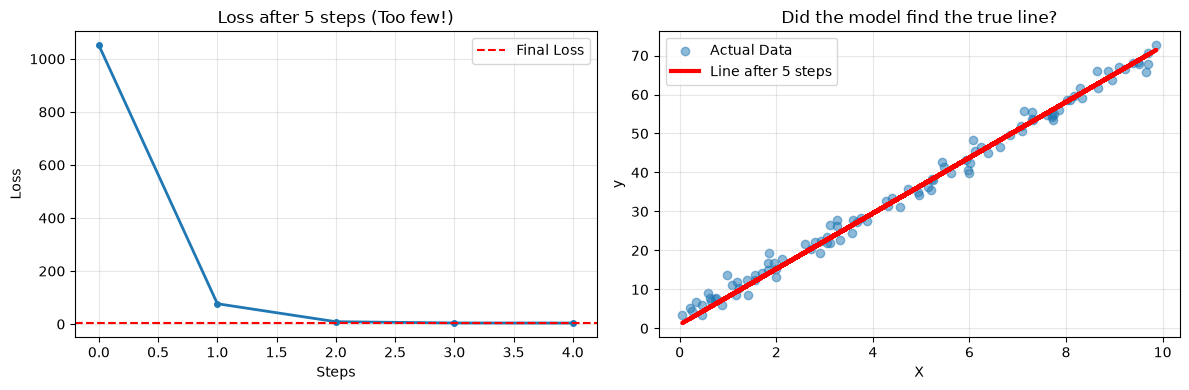

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# 1. CREATE DATA (Hidden rule: y = 7x + 2)
# -------------------------------
np.random.seed(42)
X = np.random.rand(100, 1) * 10
y = 7 * X + 2 + np.random.randn(100, 1) * 2

# Add bias column (for intercept)
X_b = np.c_[np.ones((100, 1)), X]

# -------------------------------
# 2. GRADIENT DESCENT (Only 50 steps)
# -------------------------------
learning_rate = 0.02
n_iterations = 50   # <--- TOO FEW STEPS!

theta = np.random.randn(2, 1)  # Random start
loss_history = []

print("Starting Gradient Descent...")
print(f"Step 0: Loss = ? (starting random line)\n")

for iteration in range(n_iterations):
    y_pred = X_b @ theta
    loss = (1/len(X_b)) * np.sum((y_pred - y) ** 2)
    loss_history.append(loss)
    
    gradients = (2/len(X_b)) * X_b.T @ (y_pred - y)
    theta = theta - learning_rate * gradients
    
    # Print progress every 10 steps
    if iteration % 10 == 0:
        print(f"Step {iteration}: Loss = {loss:.4f} | Line: y = {theta[1][0]:.2f}x + {theta[0][0]:.2f}")

print("\n--- FINAL RESULT ---")
print(f"Final Line after 50 steps: y = {theta[1][0]:.2f}x + {theta[0][0]:.2f}")
print(f"Expected Line:           y = 7.00x + 2.00")

# -------------------------------
# 3. VISUALIZE THE RESULT
# -------------------------------
plt.figure(figsize=(12, 4))

# Plot 1: Loss over steps
plt.subplot(1, 2, 1)
plt.plot(loss_history, marker='o', linestyle='-', linewidth=2, markersize=4)
plt.axhline(y=loss_history[-1], color='red', linestyle='--', label='Final Loss')
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.title(f"Loss after {n_iterations} steps (Too few!)")
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Data + Final Line
plt.subplot(1, 2, 2)
plt.scatter(X, y, alpha=0.5, label="Actual Data")
plt.plot(X, X_b @ theta, color='red', linewidth=3, label=f'Line after {n_iterations} steps')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.title("Did the model find the true line?")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

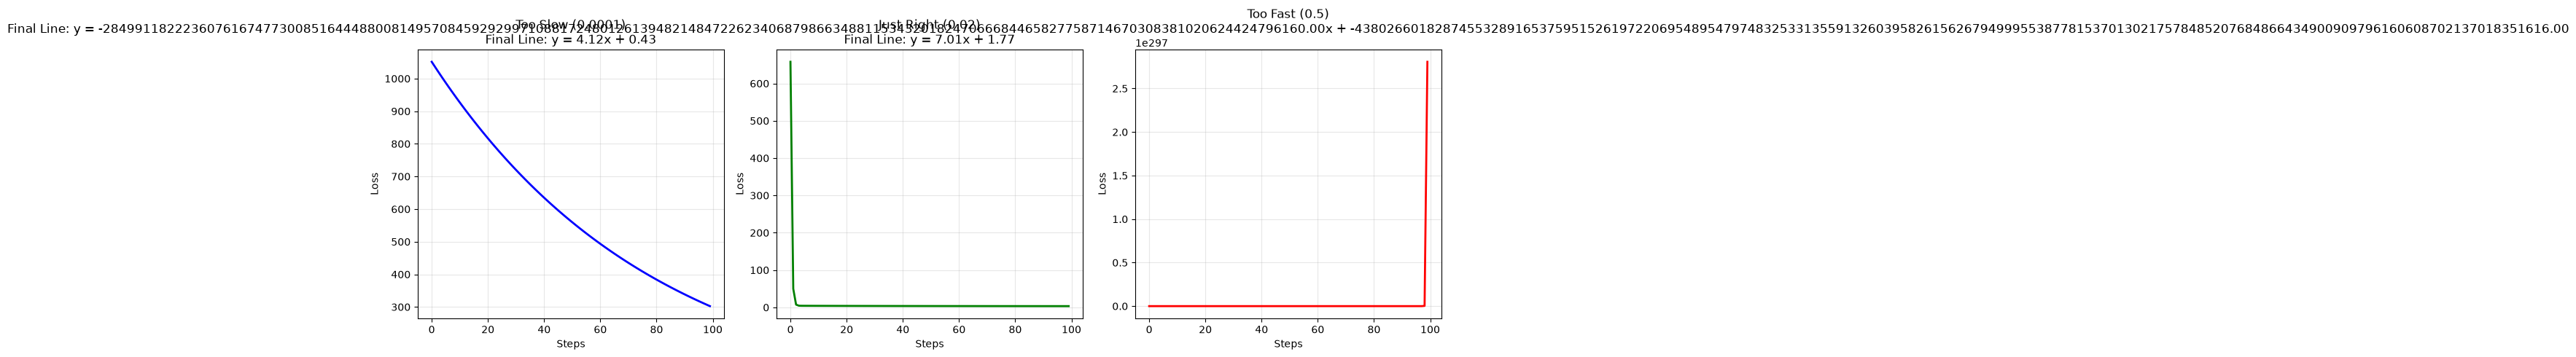

In [7]:

# -------------------------------
# 1. CREATE SAME DATA
# -------------------------------
np.random.seed(42)
X = np.random.rand(100, 1) * 10
y = 7 * X + 2 + np.random.randn(100, 1) * 2
X_b = np.c_[np.ones((100, 1)), X]

# -------------------------------
# 2. TEST 3 LEARNING RATES
# -------------------------------
learning_rates = [0.0001, 0.02, 0.5]
colors = ['blue', 'green', 'red']
labels = ['Too Slow (0.0001)', 'Just Right (0.02)', 'Too Fast (0.5)']
n_iterations = 100

plt.figure(figsize=(15, 5))

for idx, (lr, color, label) in enumerate(zip(learning_rates, colors, labels)):
    theta = np.random.randn(2, 1)
    loss_history = []
    
    # Run Gradient Descent
    for _ in range(n_iterations):
        y_pred = X_b @ theta
        loss = (1/len(X_b)) * np.sum((y_pred - y) ** 2)
        loss_history.append(loss)
        gradients = (2/len(X_b)) * X_b.T @ (y_pred - y)
        theta = theta - lr * gradients
    
    # Plot Loss
    plt.subplot(1, 3, idx + 1)
    plt.plot(loss_history, color=color, linewidth=2)
    plt.xlabel("Steps")
    plt.ylabel("Loss")
    plt.title(f"{label}\nFinal Line: y = {theta[1][0]:.2f}x + {theta[0][0]:.2f}")
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:
import numpy as np
from sklearn.linear_model import LinearRegression

# Data
np.random.seed(42)
X = np.random.rand(100, 1) * 10
y = 7 * X + 2 + np.random.randn(100, 1) * 2

# ---------- YOUR MANUAL CODE (from Day 1) ----------
X_b = np.c_[np.ones((100, 1)), X]
theta = np.random.randn(2, 1)
learning_rate = 0.02
n_iterations = 1000

for _ in range(n_iterations):
    y_pred = X_b @ theta
    gradients = (2/len(X_b)) * X_b.T @ (y_pred - y)
    theta = theta - learning_rate * gradients

manual_slope = theta[1][0]
manual_intercept = theta[0][0]

# ---------- SKLEARN (3 lines) ----------
model = LinearRegression()
model.fit(X, y)
sklearn_slope = model.coef_[0][0]
sklearn_intercept = model.intercept_[0]

# ---------- COMPARE ----------
print("=" * 50)
print("MANUAL vs SKLEARN")
print("=" * 50)
print(f"Manual Slope:     {manual_slope:.6f}")
print(f"Sklearn Slope:    {sklearn_slope:.6f}")
print(f"Difference:       {abs(manual_slope - sklearn_slope):.10f}")
print()
print(f"Manual Intercept: {manual_intercept:.6f}")
print(f"Sklearn Intercept:{sklearn_intercept:.6f}")
print(f"Difference:       {abs(manual_intercept - sklearn_intercept):.10f}")

MANUAL vs SKLEARN
Manual Slope:     6.908049
Sklearn Slope:    6.908045
Difference:       0.0000033888

Manual Intercept: 2.430170
Sklearn Intercept:2.430192
Difference:       0.0000220487
